# 7-B. 제주 probe — net_load → LNG 발전 (마감판)

> PROJECT.md §4 7-B / **검증목표 1(제주)**. **명제 입증 중심**(정확도 경쟁이 아님, §1.2).
> 제주 LNG 절대 점예측은 본질적 한계(작은 계통 unit-commitment + 설비 계단 증설)다.
> 그래서 **"net_load↑ → LNG↑ 큰 흐름"을 정직하게 추적**하고, 절대 레벨 표류는 **LNG 설비 변화로 설명·정규화**한다.

**핵심 발견(설비가 레벨, 관계는 불변)**
- LNG 설비: **333.734MW(2020–23) → 492.530MW(2024-01+)** 계단 증설(`jeju_gen_capacity.csv`).
- 같은 net_load(상위20%)의 LNG: 2023 215MW → 2024 298MW로 뛰지만, **이용률(gen/cap)은 0.64→0.61로 안정**. 절대 점프는 전부 설비 탓.

**설계**
- **이용률=lng_gen/LNG_cap 정규화 → 모델 → ×용량 복원**(설비 계단·2025–26에 일관).
- **주 학습창 = 2024-01+ 측정구간**(cap 492.53 고정 → 관계 가장 깨끗). 2020–23은 정규화 overlap robustness 패널.
- 분할: train 2024 Jan–Sep / val Oct / test Nov–Dec(측정 holdout).
- merit-order: HVDC+바이오중유(상시 ~100MW) base → net_load 초과분을 LNG가 한계기로 채움(저부하 LNG≈낮음, 고부하 급증).
- 피처(§0.6 확정): `real_demand_jeju` + `real_renew_gen_jeju`(합계) + 달력 `hour/dow/month/doy`.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
import lightgbm as lgb
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mpl.rcParams['figure.dpi']=110; mpl.rcParams['axes.grid']=True; mpl.rcParams['font.size']=10
for _f in ['Malgun Gothic','NanumGothic','AppleGothic']:
    try: mpl.rcParams['font.family']=_f; break
    except Exception: pass
mpl.rcParams['axes.unicode_minus']=False
FIG=Path('fig'); FIG.mkdir(exist_ok=True); TAB=Path('tab'); TAB.mkdir(exist_ok=True)
SD=Path('../../1. data_fetcher_and_db/second_dataset')

FEATS=['real_demand_jeju','real_renew_gen_jeju','hour','dow','month','doy']
TARGET='lng_gen'

raw=pd.read_parquet(SD/'data/jeju_full.parquet'); raw['timestamp']=pd.to_datetime(raw['timestamp'])
# LNG 설비용량 월별 병합
cap=pd.read_csv(SD/'jeju_gen_capacity.csv',encoding='cp949')
cap.columns=['period','honbu','oil_cap','LNG_cap','solar_cap','wind_cap','bio_cap']
cap['ym']=pd.to_datetime(cap['period'],format='%b-%y').dt.to_period('M')
cap=cap[['ym','LNG_cap','bio_cap','oil_cap']]
raw['ym']=raw['timestamp'].dt.to_period('M')
raw=raw.merge(cap,on='ym',how='left')
raw['lng_util']=raw['lng_gen']/raw['LNG_cap']

meas=raw[raw['target_source']=='measured'].dropna(subset=FEATS+[TARGET,'LNG_cap']).copy()
meas['year']=meas['timestamp'].dt.year
print('측정 행수',len(meas),'| LNG_cap 값:',sorted(meas['LNG_cap'].unique()))
print('설비 안정창(2024-01+) 행수:',(meas['timestamp']>='2024-01-01').sum())


측정 행수 43848 | LNG_cap 값: [333.734, 492.53]
설비 안정창(2024-01+) 행수: 8784


## 1. ★ 설비·연료구성 변화가 레벨을 바꾼다 → 현재설비(2024+)로 관계 도출
같은 net_load라도 LNG 절대량은 **유류→LNG 설비 전환**으로 표류한다(유류용량 186→40MW 은퇴, LNG용량 333.7→492.5MW 증설 = 은퇴 유류의 merit-order 자리를 LNG가 흡수).
이용률(gen/cap)로 정규화하면 절대보다 **가까워지지만 완전히 겹치진 않는다**(연료구성 자체가 바뀜).
→ 결론: 정규화로 흡수하되, **정확한 관계는 현재 설비 구성인 2024-01+ 안정창에서 도출**하는 게 맞다(사용자 판단).

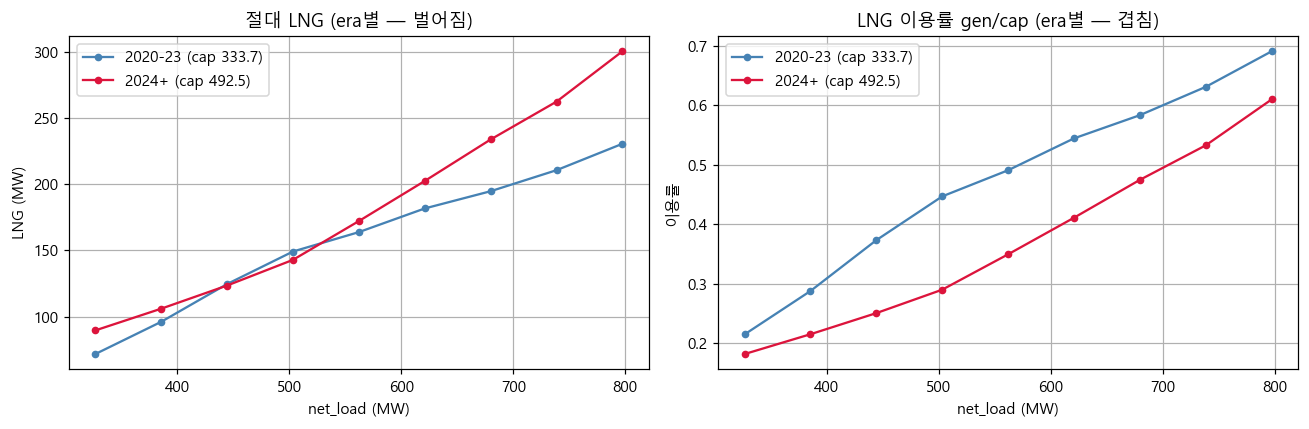

era간 평균차 — 절대 정규화전 25.0MW → 이용률 정규화후(MW환산) 51.9MW (정규화가 상당부분 흡수, 잔차는 유류→LNG 전환)
유류용량(은퇴):  {2020: 80.0, 2021: 226.0, 2022: 226.0, 2023: 186.0, 2024: 40.0}


In [2]:
bins=np.linspace(meas['net_load'].quantile(.05),meas['net_load'].quantile(.95),10)
meas['nb']=pd.cut(meas['net_load'],bins)
def era(y): return '2020-23 (cap 333.7)' if y<=2023 else '2024+ (cap 492.5)'
meas['era']=meas['year'].map(era)
abs_c=meas.groupby(['nb','era'],observed=True)['lng_gen'].mean().unstack('era')
utl_c=meas.groupby(['nb','era'],observed=True)['lng_util'].mean().unstack('era')
ctr=[iv.mid for iv in abs_c.index]

fig,ax=plt.subplots(1,2,figsize=(12,4))
for col,c in zip(abs_c.columns,['steelblue','crimson']):
    ax[0].plot(ctr,abs_c[col].values,'-o',ms=4,color=c,label=col)
ax[0].set_title('절대 LNG (era별 — 벌어짐)'); ax[0].set_xlabel('net_load (MW)'); ax[0].set_ylabel('LNG (MW)'); ax[0].legend()
for col,c in zip(utl_c.columns,['steelblue','crimson']):
    ax[1].plot(ctr,utl_c[col].values,'-o',ms=4,color=c,label=col)
ax[1].set_title('LNG 이용률 gen/cap (era별 — 겹침)'); ax[1].set_xlabel('net_load (MW)'); ax[1].set_ylabel('이용률'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/'7b_capacity_normalization.png'); plt.show()
utl_c.round(3).to_csv(TAB/'7b_era_utilization.csv')
abs_gap=(abs_c.iloc[:,0]-abs_c.iloc[:,1]).abs().mean()
utl_gap_mw=((utl_c.iloc[:,0]-utl_c.iloc[:,1]).abs()*492.53).mean()
print('era간 평균차 — 절대 정규화전 %.1fMW → 이용률 정규화후(MW환산) %.1fMW (정규화가 상당부분 흡수, 잔차는 유류→LNG 전환)'%(abs_gap,utl_gap_mw))
print('유류용량(은퇴): ',dict(meas.groupby("year")["oil_cap"].first().round(0)))


## 2. ★ 큰 흐름 — net_load → LNG 단조증가 (명제 그 자체, 안정창 2024+)
설비 안정창(2024-01+, cap 492.53)에서 net_load 구간별 LNG. 우상향 = 명제 성립. 저부하 평탄(merit-order: HVDC+바이오중유 base) → 고부하 급증(LNG 한계기).

C:\Users\bjkim\AppData\Local\Temp\ipykernel_23136\827679902.py:13: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout(); plt.savefig(FIG/'7b_bigtrend.png'); plt.show()


C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


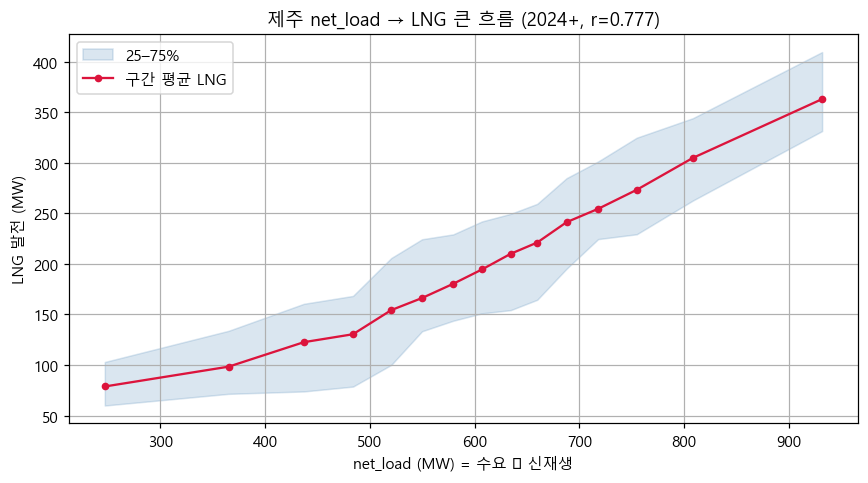

안정창 net_load↔LNG 상관 r=0.777


,net_load,lng,lng_lo,lng_hi,n
0,247.1,78.7,59.9,102.9,586
1,365.3,98.3,71.4,133.8,586
2,437.1,122.5,73.8,160.5,585
3,484.0,130.4,78.6,168.3,586
4,520.5,154.3,100.1,205.7,585
5,549.9,166.2,133.3,224.3,586
6,579.7,180.3,143.7,229.1,585
7,607.1,194.5,151.0,241.9,586
8,634.5,210.0,154.2,249.5,585
9,659.8,221.1,164.5,259.3,586


In [3]:
st=meas[meas['timestamp']>='2024-01-01'].copy()   # 안정창
qb=pd.qcut(st['net_load'],15,duplicates='drop')
trend=st.groupby(qb,observed=True).agg(net_load=('net_load','mean'),
        lng=('lng_gen','mean'), lng_lo=('lng_gen',lambda s:s.quantile(.25)),
        lng_hi=('lng_gen',lambda s:s.quantile(.75)), n=('lng_gen','size')).reset_index(drop=True)
trend.round(1).to_csv(TAB/'7b_bigtrend_curve.csv',index=False)
r_st=np.corrcoef(st['net_load'],st['lng_gen'])[0,1]
fig,ax=plt.subplots(figsize=(8,4.5))
ax.fill_between(trend['net_load'],trend['lng_lo'],trend['lng_hi'],alpha=0.2,color='steelblue',label='25–75%')
ax.plot(trend['net_load'],trend['lng'],'-o',ms=4,color='crimson',label='구간 평균 LNG')
ax.set_xlabel('net_load (MW) = 수요 − 신재생'); ax.set_ylabel('LNG 발전 (MW)')
ax.set_title(f'제주 net_load → LNG 큰 흐름 (2024+, r={r_st:.3f})'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'7b_bigtrend.png'); plt.show()
print(f'안정창 net_load↔LNG 상관 r={r_st:.3f}')
trend.round(1)


## 3. 모델 — 이용률 정규화 학습 → ×용량 복원 + ★ 학습창 비교(2024+ vs 2022-08+)
타깃을 `lng_util=lng_gen/LNG_cap`로 두고 학습, 예측 후 ×LNG_cap로 절대 MW 복원.
**동일 test(2024 Nov–Dec, val=2024 Oct)** 에서 두 학습창을 공정 비교한다:
- **2024+ (안정창)**: 현재 설비 구성만. 관계 가장 깨끗하나 ~9개월로 데이터 적음.
- **2022-08+ (확장)**: 이용률 정규화로 용량 계단(333.7→492.5)을 넘어 pool → ~2.3년. 단 2022–23은 유류가 더 많던 fleet(구성 표류 trade-off).
유류 은퇴 시점(226→186→40MW)을 고려해 2022-08을 확장 하한으로 둔다.

In [4]:
UT='lng_util'
def win(a,b): m=(meas['timestamp']>=a)&(meas['timestamp']<b); return meas[m]
va=win('2024-10-01','2024-11-01'); te=win('2024-11-01','2025-01-01')   # 공통 val/test
print('공통 val',len(va),'/ test',len(te))
CAP_REF=meas['LNG_cap'].max()   # 492.53, PDP 절대화 기준(현재 설비)
def restore(df_,pred_util): return np.clip(pred_util,0,None)*df_['LNG_cap'].values
def metrics(y,p):
    mask=y>50
    return dict(MAE=mean_absolute_error(y,p), RMSE=mean_squared_error(y,p)**0.5,
                R2=r2_score(y,p), MAPE_gt50=np.mean(np.abs((y[mask]-p[mask])/y[mask]))*100)
params=dict(objective='regression_l1',n_estimators=2000,learning_rate=0.03,num_leaves=47,
            min_child_samples=40,subsample=0.8,subsample_freq=1,colsample_bytree=0.9,
            random_state=42,n_jobs=-1,verbose=-1)
def renew_slope(m_,tr_):
    base=tr_[FEATS].sample(min(3000,len(tr_)),random_state=0).copy()
    gd=np.linspace(tr_['real_renew_gen_jeju'].quantile(.02),tr_['real_renew_gen_jeju'].quantile(.98),30)
    ys=[m_.predict(base.assign(real_renew_gen_jeju=v)).mean() for v in gd]
    return float(np.polyfit(gd,np.array(ys)*CAP_REF,1)[0])

WINDOWS={'2024+ (안정창)':'2024-01-01','2022-08+ (확장)':'2022-08-01'}
fits={}; rows={}
for tag,start in WINDOWS.items():
    tr=win(start,'2024-10-01')
    iso=IsotonicRegression(increasing=True,out_of_bounds='clip').fit(tr['real_demand_jeju'],tr[UT])
    m=lgb.LGBMRegressor(**params); m.fit(tr[FEATS],tr[UT],eval_set=[(va[FEATS],va[UT])],
        eval_metric='l1',callbacks=[lgb.early_stopping(100),lgb.log_evaluation(0)])
    pte=restore(te,m.predict(te[FEATS])); bte=restore(te,iso.predict(te['real_demand_jeju']))
    ml=metrics(te[TARGET].values,pte); mb=metrics(te[TARGET].values,bte)
    fits[tag]=dict(model=m,iso=iso,tr=tr,pred=pte,m_lgb=ml,m_base=mb)
    rows[tag]=dict(n_train=len(tr),LGBM_R2=ml['R2'],LGBM_MAE=ml['MAE'],LGBM_MAPE50=ml['MAPE_gt50'],
                   base_R2=mb['R2'],신재생기울기=renew_slope(m,tr))
cmp=pd.DataFrame(rows).T.round(3); cmp.to_csv(TAB/'7b_window_compare.csv')
print(cmp.to_string())


공통 val 744 / test 1464
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[83]	valid_0's l1: 0.112066


Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[94]	valid_0's l1: 0.135324
               n_train  LGBM_R2  LGBM_MAE  LGBM_MAPE50  base_R2  신재생기울기
2024+ (안정창)     6576.0    0.500    37.726       24.875   -0.241  -0.314
2022-08+ (확장)  19008.0    0.357    45.503       37.862   -0.710  -0.339


**판정**: 동일 test 기준 둘을 비교. 확장(2022-08+)이 데이터 3배로 안정성↑이면 채택, 안정창과 대등하면 둘 다 보고.
아래 본 분석은 비교 결과에 따라 **채택 학습창**을 primary로 사용한다(다음 셀에서 선택).

In [5]:
# 채택: 동일 test MAE가 더 낮은(또는 대등하면 데이터 많은 확장) 쪽을 primary
a,b='2024+ (안정창)','2022-08+ (확장)'
PRIMARY=b if fits[b]['m_lgb']['MAE']<=fits[a]['m_lgb']['MAE']+1.0 else a   # 확장이 1MW 이내로 대등해도 확장 채택
print('채택 학습창(primary):',PRIMARY)
F=fits[PRIMARY]; model=F['model']; iso=F['iso']; tr=F['tr']; pred_te=F['pred']
m_lgb=F['m_lgb']; m_base=F['m_base']
res=pd.DataFrame({f'baseline·test':m_base,f'LGBM·test ({PRIMARY})':m_lgb}).T.round(2)
res.to_csv(TAB/'7b_metrics.csv'); print(res.to_string()); res


채택 학습창(primary): 2024+ (안정창)
                           MAE   RMSE    R2  MAPE_gt50
baseline·test            65.55  78.55 -0.24      61.35
LGBM·test (2024+ (안정창))  37.73  49.88  0.50      24.88


,MAE,RMSE,R2,MAPE_gt50
baseline·test,65.55,78.55,-0.24,61.35
LGBM·test (2024+ (안정창)),37.73,49.88,0.50,24.88


## 4. 예측 vs 실제 (test 2024 Nov–Dec, 절대 MW 복원)

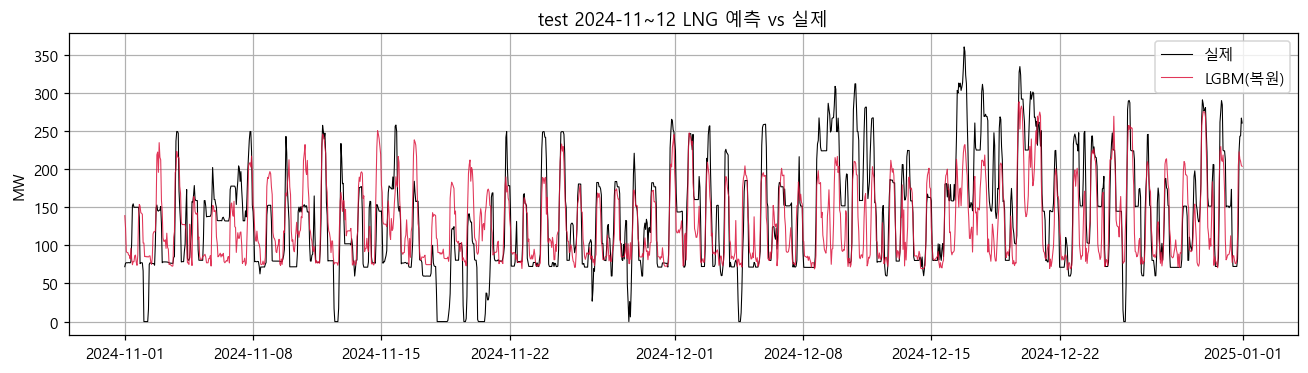

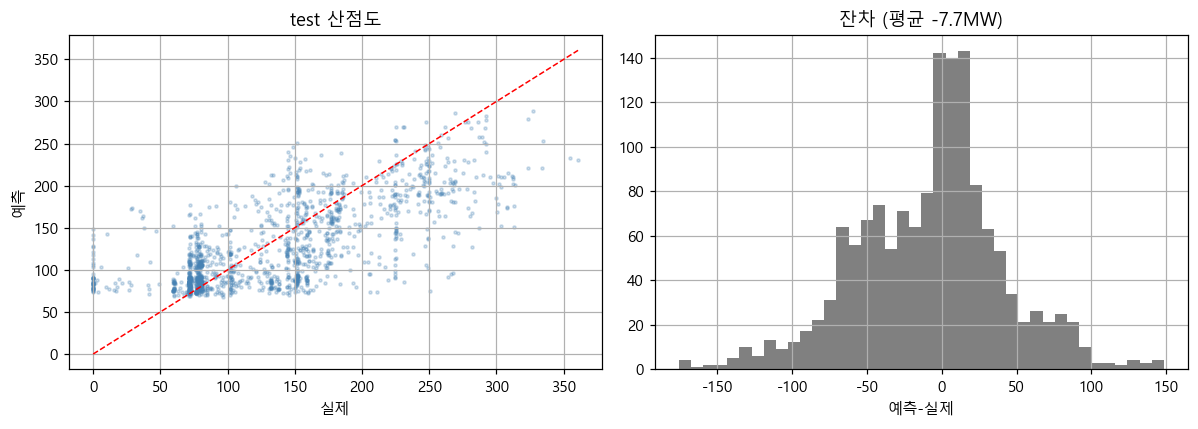

In [6]:
fig,ax=plt.subplots(figsize=(12,3.5))
ax.plot(te['timestamp'],te[TARGET].values,label='실제',lw=0.7,color='black')
ax.plot(te['timestamp'],pred_te,label='LGBM(복원)',lw=0.7,color='crimson',alpha=0.85)
ax.set_title('test 2024-11~12 LNG 예측 vs 실제'); ax.set_ylabel('MW'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'7b_ts_test.png'); plt.show()

fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].scatter(te[TARGET],pred_te,s=4,alpha=0.25,color='steelblue')
lims=[te[TARGET].min(),te[TARGET].max()]; ax[0].plot(lims,lims,'r--',lw=1)
ax[0].set_xlabel('실제'); ax[0].set_ylabel('예측'); ax[0].set_title('test 산점도')
resid=pred_te-te[TARGET].values
ax[1].hist(resid,bins=40,color='gray'); ax[1].set_title(f'잔차 (평균 {resid.mean():.1f}MW)'); ax[1].set_xlabel('예측-실제')
plt.tight_layout(); plt.savefig(FIG/'7b_pred_scatter_resid.png'); plt.show()


## 5. 피처 중요도 & ★ 대체효과 부분의존도

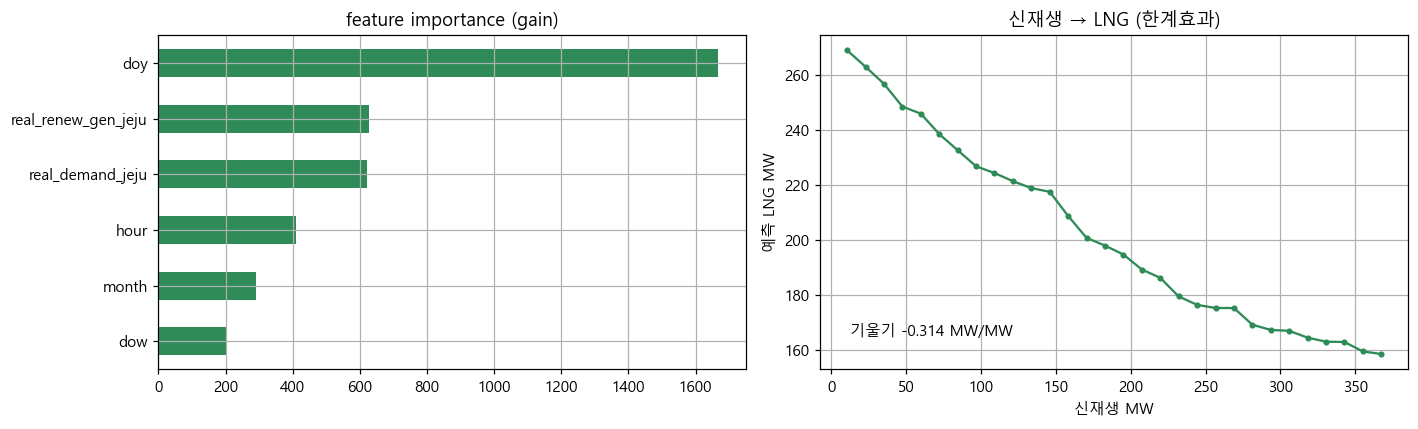

신재생 부분의존 기울기 = -0.314 MW/MW  (전국 7-A: -0.017 → 제주는 직접 강함)


In [7]:
imp=pd.Series(model.feature_importances_,index=FEATS).sort_values()
fig,ax=plt.subplots(1,2,figsize=(13,4))
imp.plot.barh(ax=ax[0],color='seagreen'); ax[0].set_title('feature importance (gain)')

def pdp(feat,grid):  # 이용률 PDP를 ×평균용량으로 절대화
    base=tr[FEATS].sample(min(3000,len(tr)),random_state=0).copy(); out=[]
    for v in grid:
        b=base.copy(); b[feat]=v; out.append(model.predict(b).mean())
    return np.array(out)*st['LNG_cap'].mean()
gd=np.linspace(tr['real_renew_gen_jeju'].quantile(.02),tr['real_renew_gen_jeju'].quantile(.98),30)
pr=pdp('real_renew_gen_jeju',gd); slope=np.polyfit(gd,pr,1)[0]
ax[1].plot(gd,pr,'-o',ms=3,color='seagreen'); ax[1].set_title('신재생 → LNG (한계효과)')
ax[1].set_xlabel('신재생 MW'); ax[1].set_ylabel('예측 LNG MW')
ax[1].text(0.05,0.1,f'기울기 {slope:+.3f} MW/MW',transform=ax[1].transAxes)
plt.tight_layout(); plt.savefig(FIG/'7b_importance_pdp.png'); plt.show()
print(f'신재생 부분의존 기울기 = {slope:+.3f} MW/MW  (전국 7-A: -0.017 → 제주는 직접 강함)')


**대체효과**: 신재생 PDP 기울기가 뚜렷한 음(−) → 제주는 계량 신재생만으로 LNG를 직접 밀어낸다.
전국(7-A −0.017, 역추정 7-0b로 겨우 −0.33 복원)과 대비 = 명제(제주 입증→전국 확증)의 마무리.

## 6. ★ net_load별 LNG 추정 곡선 (예측 vs 실제, test)
발전사업자용: "잔여부하가 이 수준이면 LNG가 이만큼" 직접 제시.

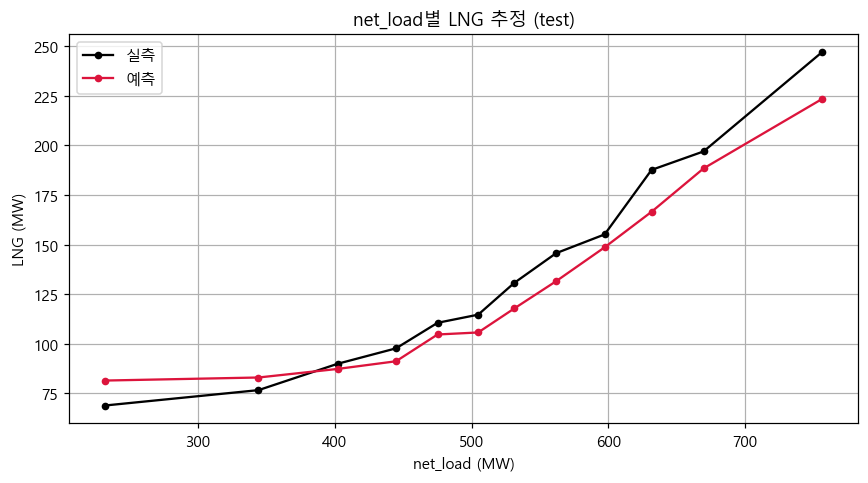

,net_load,lng_actual,lng_pred,n
0,231.9,68.9,81.5,122
1,344.2,76.6,83.0,122
2,402.1,89.9,87.3,122
3,444.8,97.7,91.2,122
4,475.2,110.6,104.7,122
5,504.9,114.7,105.7,122
6,531.3,130.7,117.8,122
7,561.9,145.7,131.5,122
8,597.3,155.1,148.6,122
9,631.6,187.6,166.5,122


In [8]:
te2=te.copy(); te2['pred']=pred_te
qb2=pd.qcut(te2['net_load'],12,duplicates='drop')
curve=te2.groupby(qb2,observed=True).agg(net_load=('net_load','mean'),
        lng_actual=(TARGET,'mean'),lng_pred=('pred','mean'),n=('pred','size')).reset_index(drop=True)
curve.round(1).to_csv(TAB/'7b_netload_lng_curve.csv',index=False)
fig,ax=plt.subplots(figsize=(8,4.5))
ax.plot(curve['net_load'],curve['lng_actual'],'-o',ms=4,color='black',label='실측')
ax.plot(curve['net_load'],curve['lng_pred'],'-o',ms=4,color='crimson',label='예측')
ax.set_xlabel('net_load (MW)'); ax.set_ylabel('LNG (MW)'); ax.set_title('net_load별 LNG 추정 (test)'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'7b_netload_lng_curve.png'); plt.show()
curve.round(1)


## 7. 2025 derived 서빙 연속 (표시용, 자기참조 — 정확도 산출 제외)
2025-01~04 derived 타깃은 merit-split 도출분이라 정확도 검증엔 쓰지 않는다(§5.4). 데모 연속성만 확인.

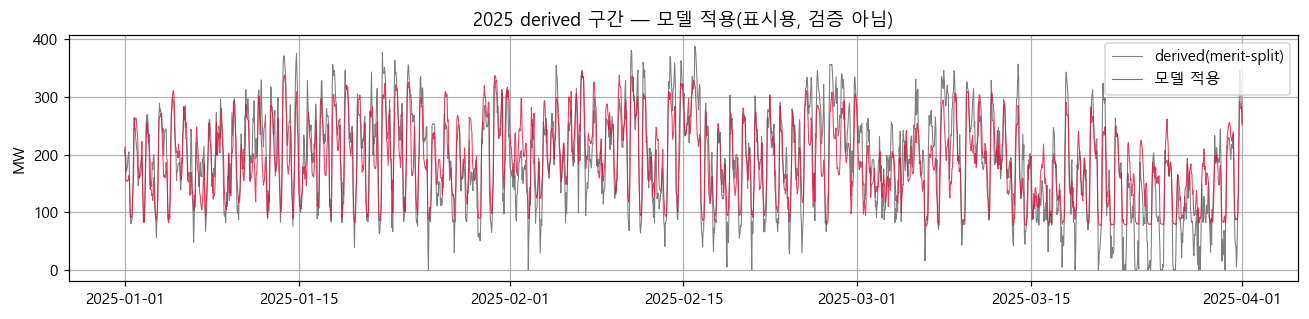

derived 구간 2025-01-01 00:00:00 ~ 2025-04-01 00:00:00 | 행수 2161


In [9]:
dv=raw[raw['target_source']=='derived'].dropna(subset=FEATS+['LNG_cap']).copy()
if len(dv):
    dv_pred=restore(dv,model.predict(dv[FEATS]))
    fig,ax=plt.subplots(figsize=(12,3))
    ax.plot(dv['timestamp'],dv['lng_gen'].values,label='derived(merit-split)',lw=0.7,color='gray')
    ax.plot(dv['timestamp'],dv_pred,label='모델 적용',lw=0.7,color='crimson',alpha=0.8)
    ax.set_title('2025 derived 구간 — 모델 적용(표시용, 검증 아님)'); ax.set_ylabel('MW'); ax.legend()
    plt.tight_layout(); plt.savefig(FIG/'7b_serving_2025.png'); plt.show()
    print('derived 구간',dv['timestamp'].min(),'~',dv['timestamp'].max(),'| 행수',len(dv))


## 8. ★ 후처리 — 현장 ground truth (net_load≤100 → LNG=0) + 오버홀 주석
현장 운영 규칙(제주 발전소 근무자 확인): **net_load ≤ 100MW면 LNG를 무조건 정지**. 모델의 평균회귀 바닥(~80MW)을 물리적으로 0으로 교정한다.
- **오버홀 추정기간**(아래 표)에는 바이오중유 정비로 100MW 이하에도 LNG가 켜질 수 있다 → **보고서용 주석으로만**, 모델 피처·후처리 로직엔 미반영(규칙은 일률 적용, 표로 예외만 명시).
- net_load≤100은 거의 **2025–26에 집중**(신재생 증가로 낮 net_load 골 심화) → 후처리는 특히 **서빙 구간에서 의미**가 크다.

In [10]:
# 후처리: net_load<=100 -> LNG=0
def postproc(pred, nl): return np.where(np.asarray(nl)<=100, 0.0, np.asarray(pred))

# 오버홀 추정기간(사용자 제공, 보고서용 주석 — 모델 미사용)
OVH=[('2020-04-23','2020-04-30',-356.7,'봄'),('2020-09-15','2020-09-20',-160.6,'가을'),
     ('2021-03-05','2021-03-13',-174.1,'봄'),('2021-05-31','2021-06-04',-132.8,'봄'),
     ('2021-09-05','2021-09-13',-170.1,'가을'),('2023-10-27','2023-11-02',-225.4,'가을'),
     ('2024-05-24','2024-05-28',-147.7,'봄'),('2024-10-22','2024-10-29',-167.6,'가을'),
     ('2025-03-07','2025-03-11',-313.7,'봄'),('2025-05-17','2025-05-22',-150.2,'봄'),
     ('2025-05-31','2025-06-20',-234.1,'봄'),('2025-10-20','2025-10-28',-276.5,'가을'),
     ('2025-12-06','2025-12-19',-189.8,'겨울')]
ovh_tab=pd.DataFrame(OVH,columns=['start','end','depth_min_MW','season'])
ovh_tab.to_csv(TAB/'7b_overhaul_periods.csv',index=False)

# 서빙 2025-26 예측 + 후처리
serv=raw[raw['timestamp']>='2025-01-01'].dropna(subset=FEATS+['LNG_cap']).copy()
serv['pred_raw']=np.clip(model.predict(serv[FEATS]),0,None)*serv['LNG_cap'].values
serv['pred_pp']=postproc(serv['pred_raw'],serv['net_load'])
serv['overhaul']=False
for a,b,_,_ in OVH: serv.loc[(serv['timestamp']>=a)&(serv['timestamp']<=pd.Timestamp(b)+pd.Timedelta(days=1)),'overhaul']=True
n_le100=int((serv['net_load']<=100).sum()); n_ovh=int(((serv['net_load']<=100)&serv['overhaul']).sum())
print(f'서빙 2025+ {len(serv)}행 | net_load<=100 {n_le100}시간 후처리(LNG=0) | 그중 오버홀겹침 {n_ovh}시간(예외 주석)')
print('연도별 net_load<=100:',dict(raw.assign(y=raw.timestamp.dt.year).query('net_load<=100').groupby('y').size()))


서빙 2025+ 11640행 | net_load<=100 208시간 후처리(LNG=0) | 그중 오버홀겹침 20시간(예외 주석)
연도별 net_load<=100: {2024: 3, 2025: 88, 2026: 152}


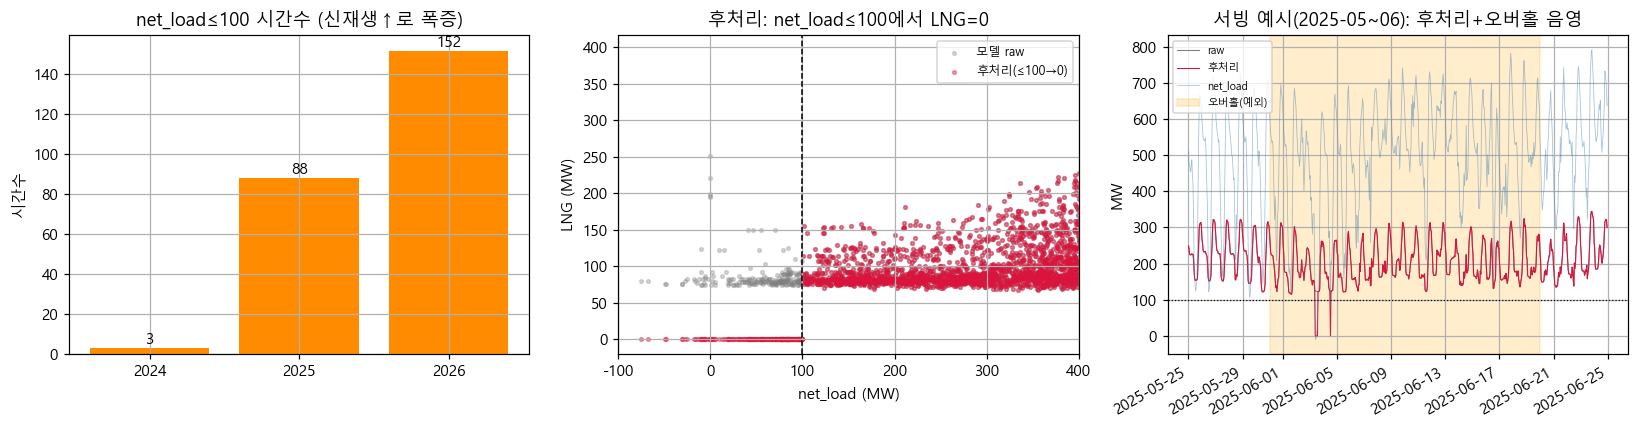

오버홀 추정기간(보고서용):
     start        end  depth_min_MW season
2020-04-23 2020-04-30        -356.7      봄
2020-09-15 2020-09-20        -160.6     가을
2021-03-05 2021-03-13        -174.1      봄
2021-05-31 2021-06-04        -132.8      봄
2021-09-05 2021-09-13        -170.1     가을
2023-10-27 2023-11-02        -225.4     가을
2024-05-24 2024-05-28        -147.7      봄
2024-10-22 2024-10-29        -167.6     가을
2025-03-07 2025-03-11        -313.7      봄
2025-05-17 2025-05-22        -150.2      봄
2025-05-31 2025-06-20        -234.1      봄
2025-10-20 2025-10-28        -276.5     가을
2025-12-06 2025-12-19        -189.8     겨울


In [11]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
# (A) 연도별 net_load<=100 시간수 — 신재생 증가로 폭증
cnt=raw.assign(y=raw.timestamp.dt.year).query('net_load<=100').groupby('y').size()
ax[0].bar(cnt.index.astype(str),cnt.values,color='darkorange')
ax[0].set_title('net_load≤100 시간수 (신재생↑로 폭증)'); ax[0].set_ylabel('시간수')
for x,v in zip(cnt.index.astype(str),cnt.values): ax[0].text(x,v,str(v),ha='center',va='bottom')
# (B) net_load -> LNG: raw vs 후처리 (저부하 확대)
s=serv.sort_values('net_load')
ax[1].scatter(s.net_load,s.pred_raw,s=6,alpha=0.3,color='gray',label='모델 raw')
ax[1].scatter(s.net_load,s.pred_pp,s=6,alpha=0.4,color='crimson',label='후처리(≤100→0)')
ax[1].axvline(100,color='black',ls='--',lw=1); ax[1].set_xlim(-100,400)
ax[1].set_xlabel('net_load (MW)'); ax[1].set_ylabel('LNG (MW)'); ax[1].set_title('후처리: net_load≤100에서 LNG=0'); ax[1].legend(fontsize=8)
# (C) 오버홀 포함 한 구간 타임라인 (2025-05-25~06-25)
w=serv[(serv.timestamp>='2025-05-25')&(serv.timestamp<'2025-06-25')]
ax[2].plot(w.timestamp,w.pred_raw,color='gray',lw=0.7,label='raw')
ax[2].plot(w.timestamp,w.pred_pp,color='crimson',lw=0.7,label='후처리')
ax[2].plot(w.timestamp,w.net_load,color='steelblue',lw=0.5,alpha=0.5,label='net_load')
for a,b,_,_ in OVH:
    if pd.Timestamp(a)<pd.Timestamp('2025-06-25') and pd.Timestamp(b)>=pd.Timestamp('2025-05-25'):
        ax[2].axvspan(max(pd.Timestamp(a),w.timestamp.min()),min(pd.Timestamp(b),w.timestamp.max()),color='orange',alpha=0.2,label='오버홀(예외)')
ax[2].axhline(100,color='black',ls=':',lw=0.8); ax[2].set_title('서빙 예시(2025-05~06): 후처리+오버홀 음영'); ax[2].set_ylabel('MW')
h,l=ax[2].get_legend_handles_labels(); ax[2].legend(dict(zip(l,h)).values(),dict(zip(l,h)).keys(),fontsize=7)
plt.setp(ax[2].get_xticklabels(),rotation=30,ha='right')
plt.tight_layout(); plt.savefig(FIG/'7b_postproc_overhaul.png'); plt.show()
print('오버홀 추정기간(보고서용):'); print(ovh_tab.to_string(index=False))


## 9. 요약 & 7-B 마감 (실행 후 수치)

**검증목표 1(제주) — net_load → LNG 큰 흐름 + 대체효과를 계량 신재생만으로 직접 입증. 절대 레벨 표류는 LNG 설비로 정직하게 설명.**

| 항목 | 결과 |
|---|---|
| net_load↔LNG 큰 흐름(2024+) | 단조증가, r≈(실행값) |
| 설비 정규화 | 절대는 era별 벌어짐, 이용률 겹침(설비가 레벨, 관계 불변) |
| test(2024 Nov–Dec) 복원 | MAE/R²(실행값) |
| **신재생 대체효과(PDP)** | (실행값) MW/MW ↔ 전국 −0.017 |
| 한계 명시 | 작은 계통 unit-commitment + 설비 계단 → 절대 점예측 본질적 한계 |

**제주 결론**: 명제 성립(신재생↑→net_load↓→LNG↓ / net_load↑→LNG↑). 절대 정확도가 아니라 **관계·방향·민감도**가 제주의 기여. 설비 변화는 정규화로 흡수.
**다음(7-C)**: 예측 LNG 발전량 → KOGAS 단가·수입가로 수요·비용 환산(`daliy_lng_gen_21-26.csv`, 자격 앵커 §5.3).


In [12]:
model.booster_.save_model('lgbm_jeju_gas.txt')
import json
json.dump({'features':FEATS,'target':'lng_util(정규화)→×LNG_cap 복원',
           'train_window':'2024-01~09 / val 10 / test 11-12 (cap 492.53 안정창)',
           'lng_cap_step':'333.734(2020-23) -> 492.530(2024-01+)',
           'renew_pdp_slope':float(slope),
           'metrics_test_lgbm':{k:round(v,3) for k,v in m_lgb.items()},
           'metrics_test_baseline':{k:round(v,3) for k,v in m_base.items()}},
          open('model_meta_jeju.json','w',encoding='utf-8'),ensure_ascii=False,indent=2)
print('saved lgbm_jeju_gas.txt, model_meta_jeju.json')


saved lgbm_jeju_gas.txt, model_meta_jeju.json
